# 4 — Cell states and cellular neighbourhoods from virtual staining

A cellular neighborhood recurs structures within the tissue with characteristic cell compositions and interactions.
An important application of virtual staining is how to identify CNs from a virtual pipeline.

This notebook reproduces the CN case panel — region **`bog-86337`**, one esophagus core of
a held-out cohort.

Data: **bog-86337** (`data/bog-86337`) — see [Tutorial 0](./00_data.ipynb).

Virtual and real applied independent cell segmentation, cell typing and CN annotation. The classes were further
unified to showcase. In practical, the unification is not necessary

In [1]:
import _common 
import numpy as np
import matplotlib.pyplot as plt

from questkit import cohort, cn_case

RID = "bog-86337"
arms = cn_case.load_arms(cohort.BOG_ROOT)
k = arms["rids"].index(RID)
nR, nV = len(arms["real"]["reg"]), len(arms["virt"]["reg"])
print(f"real arm    {nR:,} cells over {len(arms['rids'])} regions")
print(f"virtual arm {nV:,} nuclei of its own (ratio {nV / nR:.3f}) — Mesmer on the predicted DAPI")
print(f"markers     {len(arms['markers'])}: {arms['markers']}")

real arm    135,281 cells over 16 regions
virtual arm 115,842 nuclei of its own (ratio 0.856) — Mesmer on the predicted DAPI
markers     18: ['PanCK', 'EpCAM', 'ECad', 'CD45', 'CD3e', 'CD4', 'CD8', 'FoxP3', 'CD20', 'CD68', 'CD163', 'aSMA', 'Vimentin', 'CD31', 'Ki67', 'HLA-DR', 'Podoplanin', 'MPO']


## Step 1 — Cell typing from virtual and real MIF

Cell types are clustered and annotated independently by virtual and real MIF expression.
See Supplementary Table 3 for cell type unification.

In [2]:
m = cn_case.fit_arm(arms, "real", 8, 6)     
v = cn_case.fit_arm(arms, "virt", 6, 6)      
corr = cn_case.correspondence(m, v)
selR, selV = m["reg"] == k, v["reg"] == k

for arm, sel, tag, virt in ((m, selR, "REAL MIF", False), (v, selV, "VIRTUAL MIF", True)):
    print(f"\n{tag} — K={arm['K']}, its own k-means, its own names")
    print(f"  {'cell state':<34}{'cohort':>7}{'case':>6}  {'unified category':<26}"
          f"signature (z >= 1)")
    keys = corr["key_v"] if virt else corr["key_m"]
    for i in np.argsort(-np.bincount(arm["types"][sel], minlength=arm["K"])):
        key = keys[arm["types"] == i][0]
        print(f"  {cn_case.disp(arm['names'][i], virt):<34}"
              f"{np.mean(arm['types'] == i):>7.3f}{np.mean(arm['types'][sel] == i):>6.3f}  "
              f"{cn_case.disp(key, virt):<26}{'+'.join(arm['signatures'][i][:4]) or '-'}")


REAL MIF — K=8, its own k-means, its own names
  cell state                         cohort  case  unified category          signature (z >= 1)
  macrophage                          0.337 0.535  immune                    CD45+CD68+HLA-DR+CD4
  smooth muscle/myofibroblast         0.064 0.126  stromal / smooth muscle   aSMA
  unresolved                          0.059 0.123  unresolved                Vimentin
  proliferating epithelial cell       0.267 0.097  epithelial                Ki67+CD8+EpCAM+Podoplanin
  endothelial cell                    0.054 0.088  endothelial (real only)   CD31
  T cell                              0.123 0.020  immune                    CD3e+ECad
  FoxP3/MPO-associated cell           0.018 0.010  immune                    FoxP3+MPO
  PanCK epithelial cell               0.079 0.001  epithelial                PanCK+CD3e

VIRTUAL MIF — K=6, its own k-means, its own names
  cell state                         cohort  case  unified category          signature (z >=

## Step 2 — Cellular neighbourhoods annotation

Both arms cluster their own window compositions, so their CN ids mean nothing to each other. They
are paired on their member-cell composition over the unified categories. See Supplementary Table 4 in paper.

In [3]:
NC = m["NC"]
print(f"{'':5}{'real, its own annotation':<48}{'unified category':<34}{'case':>6}")
for c in range(NC):
    print(f"  CN{c} {cn_case.disp(corr['cn_own_m'][c]):<48}"
          f"{cn_case.disp(corr['cn_uni_m'][c]):<34}{np.mean(m['cn'][selR] == c):>6.0%}")
print(f"\n{'':5}{'virtual, its own annotation':<48}{'pairs to':<34}{'case':>6}")
for c in range(NC):
    print(f"  vCN{c} {cn_case.disp(corr['cn_own_v'][c], True):<48}"
          f"{'CN%d  %s' % (corr['pair'][c], cn_case.disp(corr['cn_uni_m'][corr['pair'][c]])):<34}"
          f"{np.mean(v['cn'][selV] == c):>6.0%}")

     real, its own annotation                        unified category                    case
  CN0 proliferating epithelial cell-rich              epithelial-rich                       9%
  CN1 macrophage-rich                                 immune-rich                          44%
  CN2 macrophage–unresolved–endothelial cell mixed    immune–unresolved mixed              30%
  CN3 T cell-rich                                     T cell-rich                           2%
  CN4 PanCK epithelial cell-rich                      PanCK epithelial cell-rich            0%
  CN5 smooth muscle/myofibroblast-rich                stromal / smooth muscle-rich         15%

     virtual, its own annotation                     pairs to                            case
  vCN0 immune cell-homogeneous                         CN1  immune-rich                     66%
  vCN1 EpCAM epithelial cell-rich                      CN0  epithelial-rich                 10%
  vCN2 ECad epithelial cell-rich                 

## Showcase

This region is also shown in our published version.

6,958 real cells, 5,844 predicted nuclei, 24.5% of the mosaic had no source patch


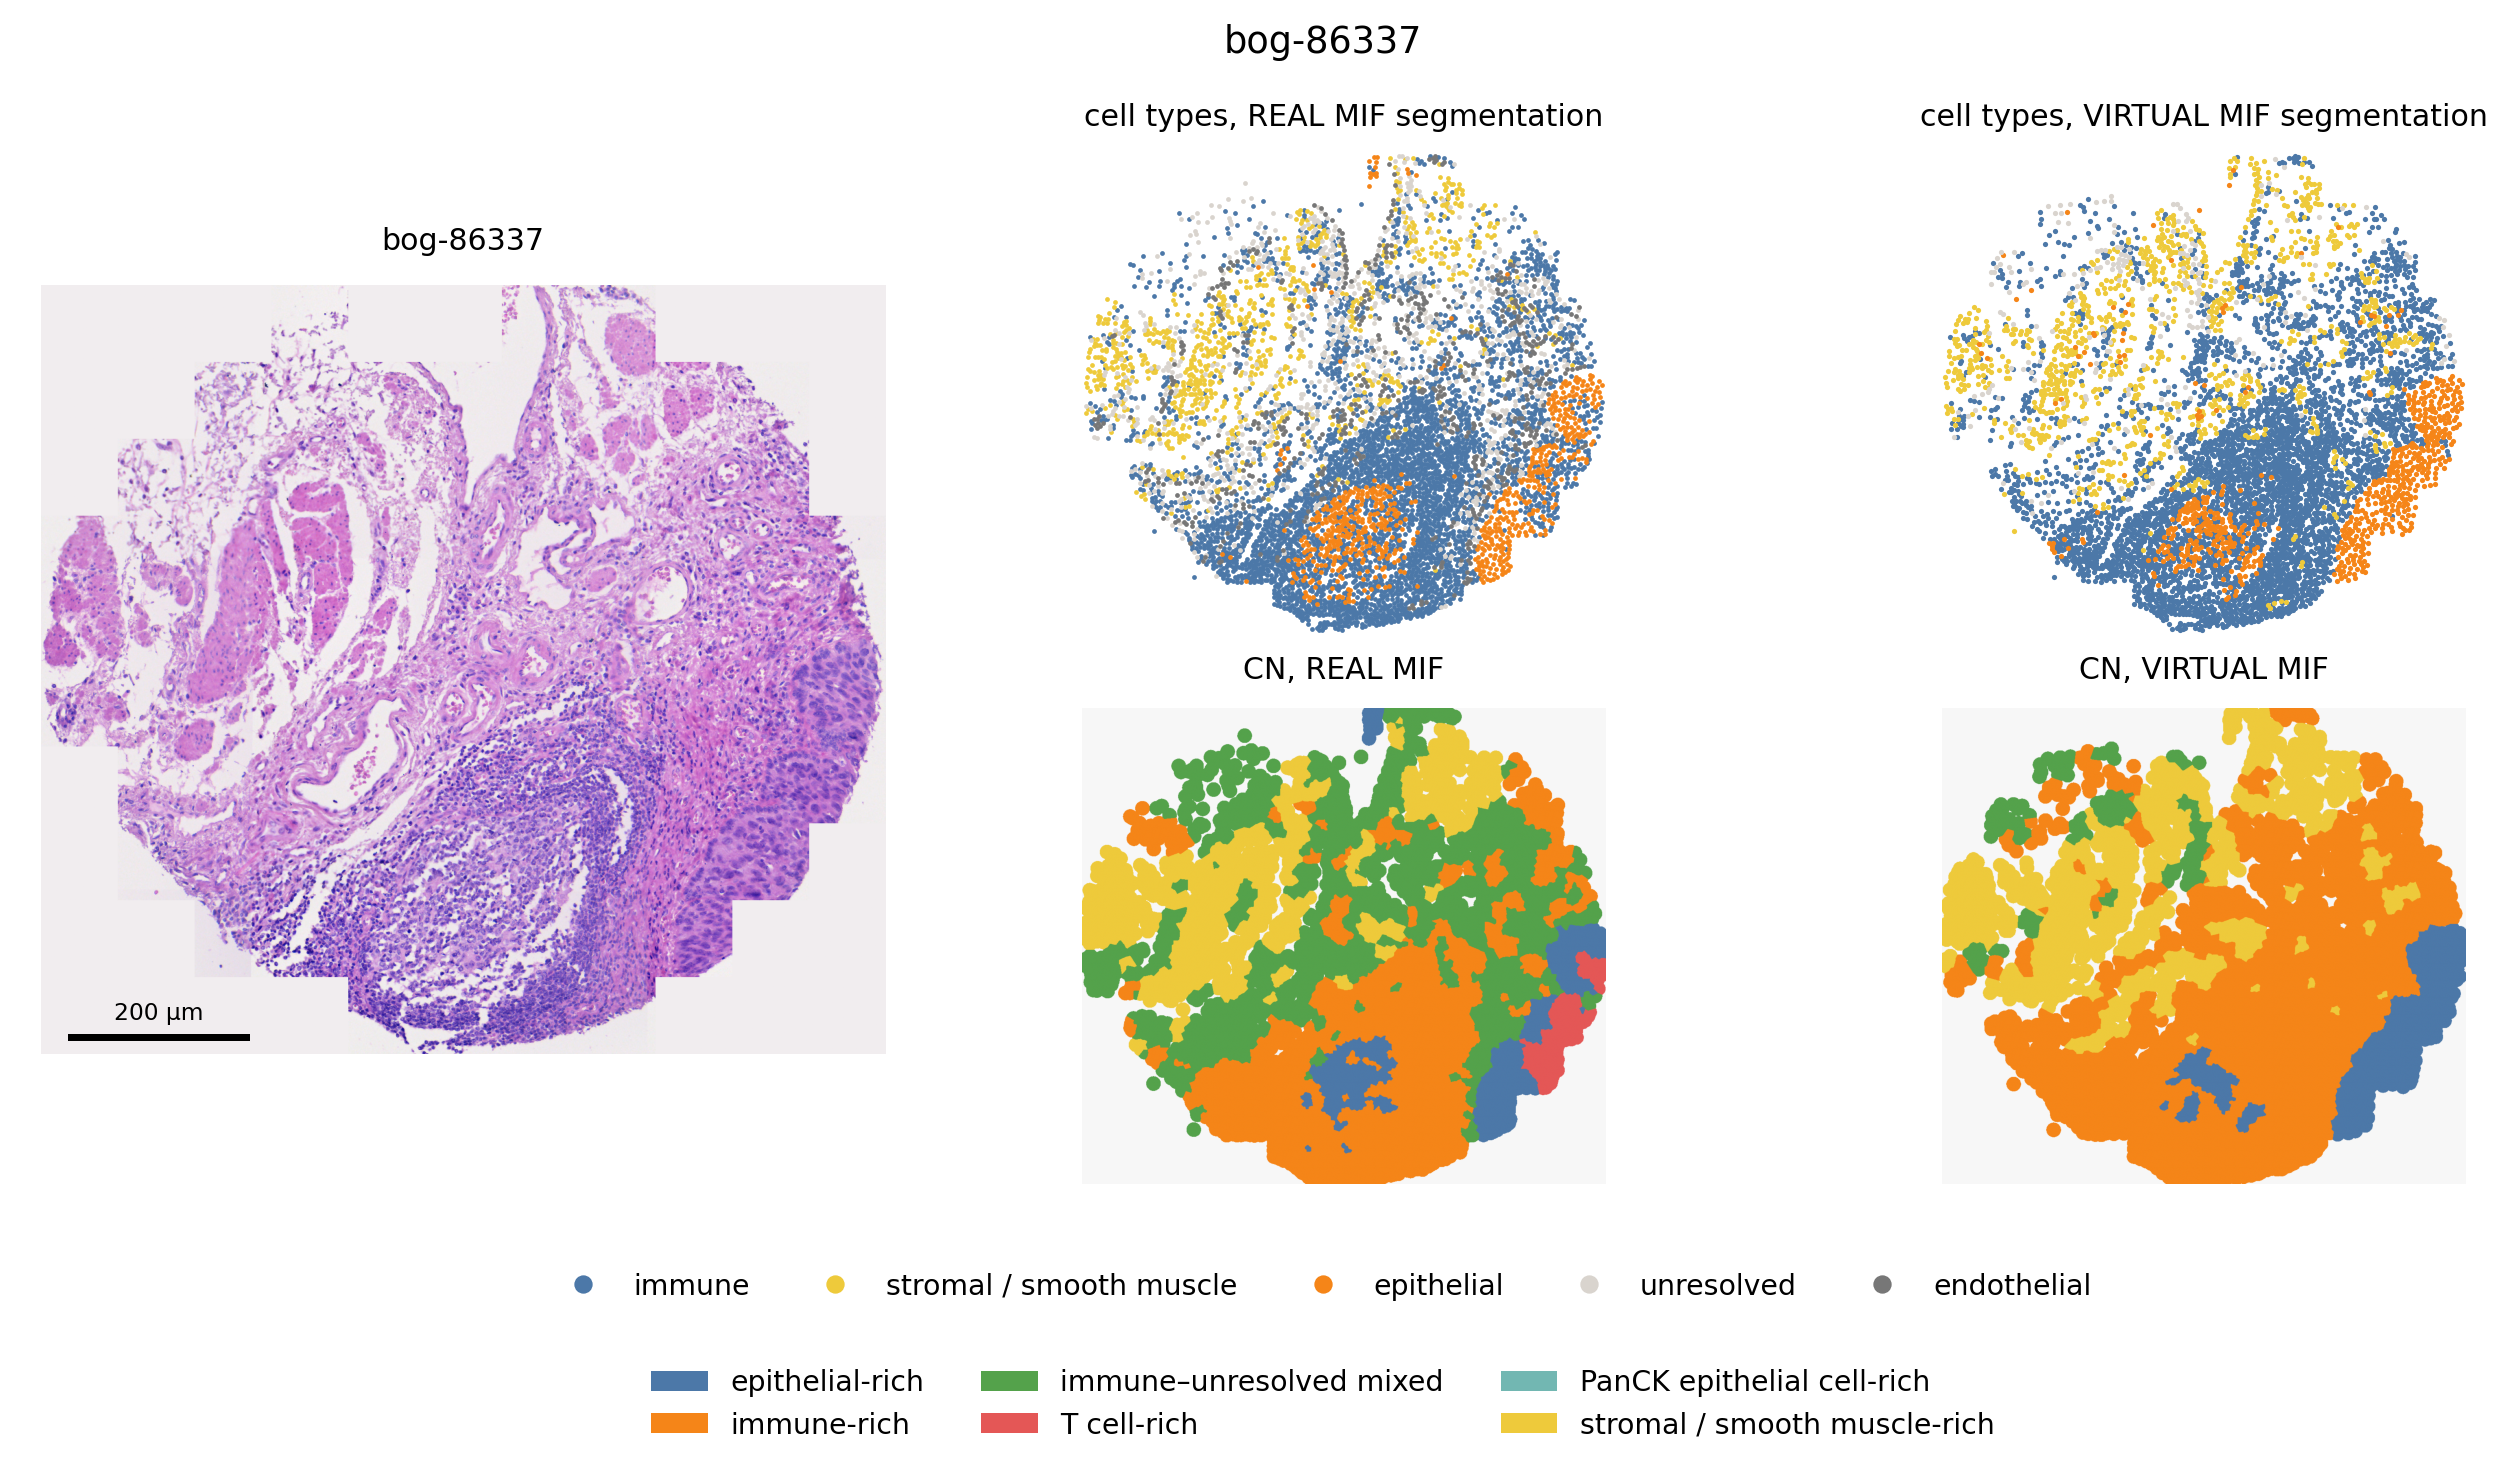

In [4]:
fig, info = cn_case.case_figure(arms, RID, m, v, corr)
print(f"{info['n_real']:,} real cells, {info['n_virtual']:,} predicted nuclei, "
      f"{info['gap_fraction']:.1%} of the mosaic had no source patch")
plt.show()